# M100 telemetry exploration

This notebook inspects the compact processed subset used by the reproducible five-minute temperature and power forecasting experiment. The production training logic remains in `src/`.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
DATA = ROOT / "data/processed/m100-thermal-subset.csv.gz"
METRICS = ROOT / "reports/metrics.json"

df = pd.read_csv(DATA, parse_dates=["timestamp"])
df["node"] = df["node"].astype(str)
print(f"Rows: {len(df):,}")
print(f"Nodes: {df['node'].nunique()}")
print(f"Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Rows: 10,068
Nodes: 12
Range: 2021-03-03 00:00:00+00:00 to 2021-03-03 13:58:00+00:00


,node,timestamp,cpu_temp_mean,cpu_temp_max,cpu_temp_sensor_count,ambient,p0_power,p1_power,total_power,p0_vdd_temp,p1_vdd_temp,cpu_user,cpu_system,cpu_idle,cpu_wio,cpu_speed,load_one,load_five,load_fifteen,cpu_busy,cpu_socket_power,hour_utc,day_of_week_utc
0,119,2021-03-03 00:00:00+00:00,64.722222,67.666667,6.0,26.133333,172.666667,159.333333,933.333333,48.666667,46.000000,65.400002,0.2,34.400002,0.0,3800.0,74.660004,82.565002,83.779999,65.599998,332.000000,0,2
1,119,2021-03-03 00:01:00+00:00,64.777778,67.333333,6.0,26.066666,125.333333,117.333333,886.666667,49.000000,46.000000,NaN,NaN,NaN,NaN,3800.0,81.849998,82.923332,83.813332,NaN,242.666667,0,2
2,119,2021-03-03 00:02:00+00:00,62.666667,64.333333,6.0,25.866667,170.000000,146.666667,973.333333,48.666667,45.666667,65.000000,0.3,34.700001,0.0,3800.0,85.646667,83.653328,84.000000,65.300003,316.666667,0,2
3,119,2021-03-03 00:03:00+00:00,64.277778,67.000000,6.0,25.933334,181.333333,148.666667,993.333333,49.333333,46.000000,65.300003,0.2,34.400002,0.0,3800.0,89.620003,85.399994,84.589996,65.500000,330.000000,0,2
4,119,2021-03-03 00:04:00+00:00,63.500000,66.666667,6.0,25.866667,134.000000,134.000000,906.666667,49.000000,46.000000,NaN,NaN,NaN,NaN,3800.0,80.840004,83.773338,84.086662,NaN,268.000000,0,2


## Missing telemetry

In [2]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing[missing > 0].to_frame("missing_percent")

,missing_percent
cpu_wio,27.205006
cpu_idle,27.195074
cpu_user,27.195074
cpu_system,27.195074
cpu_busy,27.195074
load_five,12.693683
load_one,12.693683
load_fifteen,12.693683
cpu_speed,0.367501


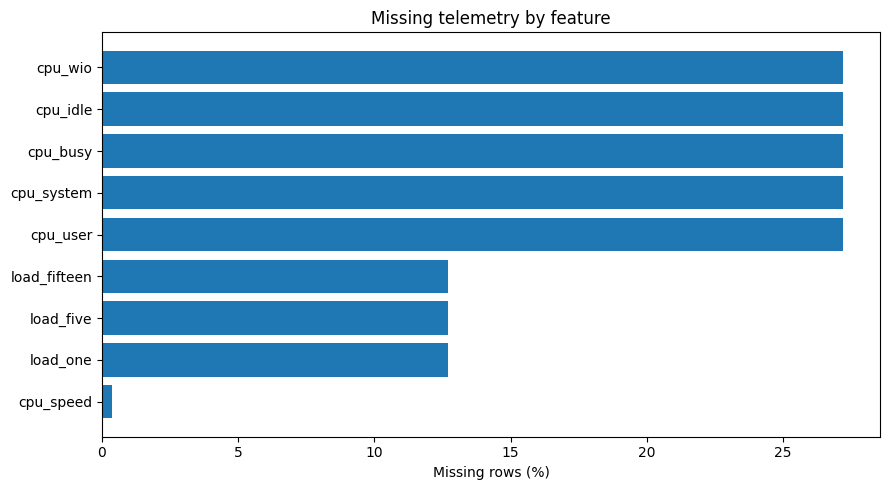

In [3]:
selected = missing[missing > 0].sort_values()
plt.figure(figsize=(9, 5))
plt.barh(selected.index, selected.values)
plt.xlabel("Missing rows (%)")
plt.title("Missing telemetry by feature")
plt.tight_layout()
plt.show()

## Node-level operating ranges

In [4]:
node_summary = df.groupby("node").agg(
    rows=("timestamp", "size"),
    temperature_mean=("cpu_temp_max", "mean"),
    temperature_min=("cpu_temp_max", "min"),
    temperature_max=("cpu_temp_max", "max"),
    power_mean=("total_power", "mean"),
    power_max=("total_power", "max"),
).round(2)
node_summary

,rows,temperature_mean,temperature_min,temperature_max,power_mean,power_max
node,,,,,,
119,839,66.77,61.00,69.67,924.57,1046.67
123,839,68.38,63.67,71.00,962.83,1126.67
151,839,57.54,41.00,66.00,945.69,1320.00
198,839,67.36,63.67,69.67,991.02,1160.00
236,839,61.32,49.33,71.67,633.22,1000.00
35,839,54.93,45.67,68.33,616.15,946.67
38,839,62.08,41.67,71.33,747.43,1366.67
419,839,69.12,64.33,71.33,1008.50,1173.33
435,839,54.15,38.33,65.00,1081.75,1313.33


## Temperature and power relationship

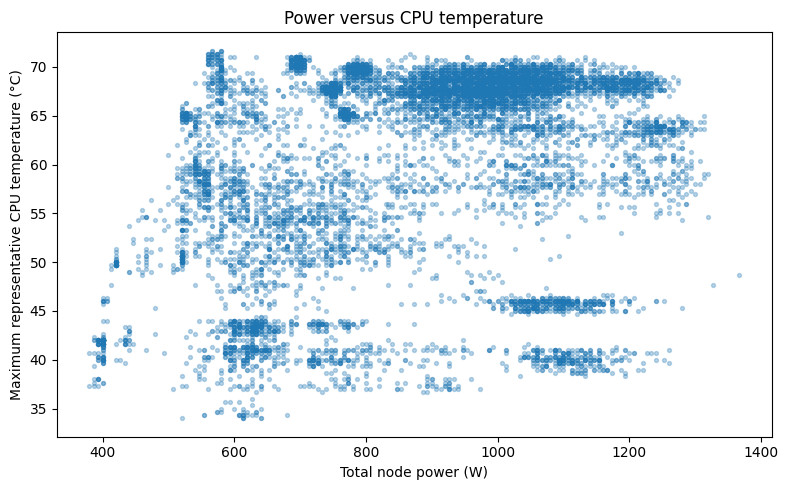

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["total_power"], df["cpu_temp_max"], s=8, alpha=0.3)
plt.xlabel("Total node power (W)")
plt.ylabel("Maximum representative CPU temperature (°C)")
plt.title("Power versus CPU temperature")
plt.tight_layout()
plt.show()

## Reproduced held-out results

In [6]:
metrics = json.loads(METRICS.read_text())
rows = []
for task, experiment in metrics["experiments"].items():
    selected = experiment["selected_model"]
    result = experiment["test_models"][selected]
    baseline = experiment["test_models"]["persistence"]
    rows.append({
        "task": task,
        "selected_model": selected,
        "mae": result["mae"],
        "rmse": result["rmse"],
        "r2": result["r2"],
        "persistence_rmse": baseline["rmse"],
        "rmse_reduction_percent": 100 * (baseline["rmse"] - result["rmse"]) / baseline["rmse"],
    })
pd.DataFrame(rows).round(3)

,task,selected_model,mae,rmse,r2,persistence_rmse,rmse_reduction_percent
0,temperature,ridge,1.186,2.022,0.921,2.273,11.039
1,power,ridge,57.428,81.164,0.816,103.625,21.675


## Notes

- The final split is chronological and based on target timestamp.
- The same 12 node identities appear across train, validation, and test.
- These results are a portfolio-scale experiment, not a production or hardware-safety validation.
- See `reports/experiment.md` for the complete methodology and limitations.